In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


In [2]:
(ds_train, ds_val), ds_info = tfds.load(
    "imagenette/160px",
    split=["train", "validation"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes
print("Number of classes:", NUM_CLASSES)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imagenette/160px/incomplete.HBRPOI_1.0.0/imagenette-train.tfrecord*...:   …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imagenette/160px/incomplete.HBRPOI_1.0.0/imagenette-validation.tfrecord*..…

Dataset imagenette downloaded and prepared to /root/tensorflow_datasets/imagenette/160px/1.0.0. Subsequent calls will reuse this data.
Number of classes: 10


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

train_ds = ds_train.map(preprocess)\
                   .shuffle(1000)\
                   .batch(BATCH_SIZE)\
                   .prefetch(tf.data.AUTOTUNE)

val_ds = ds_val.map(preprocess)\
               .batch(BATCH_SIZE)\
               .prefetch(tf.data.AUTOTUNE)


In [4]:
def build_zfnet(input_shape=(224, 224, 3), num_classes=10):
    model = Sequential(name="ZFNet")

    # 1st Convolution Layer (Smaller filter & stride than AlexNet)
    model.add(Conv2D(96, (7, 7), strides=2, activation="relu",
                     input_shape=input_shape))
    model.add(MaxPooling2D((3, 3), strides=2))

    # 2nd Convolution Layer
    model.add(Conv2D(256, (5, 5), padding="same", activation="relu"))
    model.add(MaxPooling2D((3, 3), strides=2))

    # 3rd, 4th, 5th Convolution Layers
    model.add(Conv2D(384, (3, 3), padding="same", activation="relu"))
    model.add(Conv2D(384, (3, 3), padding="same", activation="relu"))
    model.add(Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D((3, 3), strides=2))

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(4096, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(4096, activation="relu"))
    model.add(Dropout(0.5))

    # Output Layer
    model.add(Dense(num_classes, activation="softmax"))

    return model


In [5]:
zfnet = build_zfnet()

zfnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n===== ZFNET MODEL SUMMARY =====")
zfnet.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



===== ZFNET MODEL SUMMARY =====


Model: "ZFNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 109, 109, 96)   │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 54, 54, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   150,999,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,547,786 (654.40 MB)

 Trainable params: 171,547,786 (654.40 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 5

history = zfnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 100s 194ms/step - accuracy: 0.2466 - loss: 2.0568 - val_accuracy: 0.5020 - val_loss: 1.4146
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 57s 139ms/step - accuracy: 0.5470 - loss: 1.3660 - val_accuracy: 0.6700 - val_loss: 1.1123
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 58s 143ms/step - accuracy: 0.6749 - loss: 1.0137 - val_accuracy: 0.7580 - val_loss: 0.7934
Epoch 4/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 58s 142ms/step - accuracy: 0.7382 - loss: 0.7980 - val_accuracy: 0.7260 - val_loss: 0.8404
Epoch 5/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 58s 143ms/step - accuracy: 0.7901 - loss: 0.6335 - val_accuracy: 0.7420 - val_loss: 0.7720


In [7]:
loss, acc = zfnet.evaluate(val_ds)

print("\n===== ZFNET PERFORMANCE =====")
print(f"Validation Accuracy : {acc * 100:.2f}%")
print(f"Validation Loss     : {loss:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7420 - loss: 0.7828

===== ZFNET PERFORMANCE =====
Validation Accuracy : 74.20%
Validation Loss     : 0.7720


In [8]:
print("\n===== MODEL DETAILS =====")
print("Total Parameters :", f"{zfnet.count_params():,}")
print("Total Layers     :", len(zfnet.layers))



===== MODEL DETAILS =====
Total Parameters : 171,547,786
Total Layers     : 14


In [11]:
class_names = ds_info.features["label"].names

synset_to_name = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute"
}

for idx, synset in enumerate(ds_info.features["label"].names):
    print(f"{idx} : {synset_to_name[synset]}")


0 : tench
1 : English springer
2 : cassette player
3 : chain saw
4 : church
5 : French horn
6 : garbage truck
7 : gas pump
8 : golf ball
9 : parachute


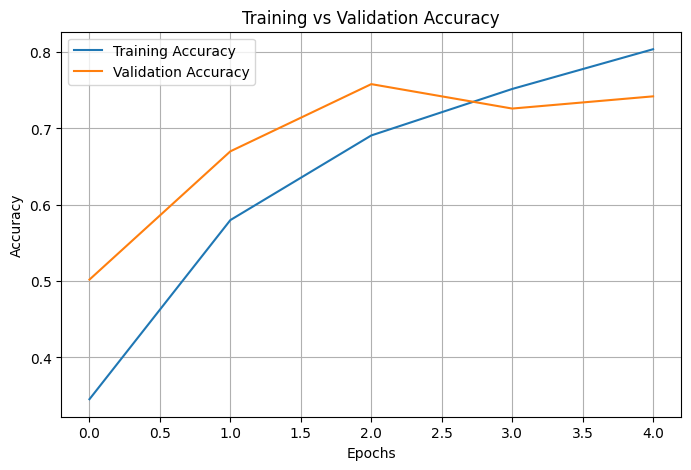

In [12]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


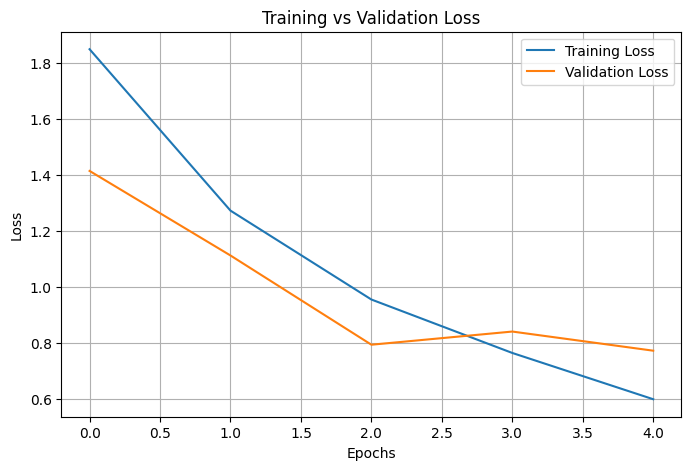

In [13]:
# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()
